<a href="https://colab.research.google.com/github/yuva0567890/23mid0421APAassignment3/blob/main/23MID0421APAassess3dataset2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================
print("K N Yuvaraj")
print("23MID0421")
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

import warnings
warnings.filterwarnings("ignore")

K N Yuvaraj
23MID0421


In [37]:
# ==========================================
# Load Dataset 2
# ==========================================

import pandas as pd

email = pd.read_csv("spam_email_dataset.csv")

email.head()

,Email,Subject,Sender,Recipient,Date,Time,Attachments,Link Count,Word Count,Uppercase Count,Exclamation Count,Question Count,Dollar Count,Punctuation Count,HTML Tags Count,Spam Indicator
0,mikerusso@example.net,Even hotel community church.,emilyscott@example.org,gregorysmith@example.org,13-02-2023,04:13,3,0,191,32,3,3,0,11,1,1
1,waynebailey@example.org,Try themselves guess fight white agreement thu...,annwhite@example.net,gonzalezdaniel@example.net,09-08-2023,06:15,3,9,45,1,2,1,2,8,2,1
2,jill43@example.com,Environmental commercial off seem any conference.,david88@example.net,michellebaker@example.net,16-05-2023,01:32,3,9,52,1,4,0,2,10,1,1
3,johnsonkaren@example.org,Smile real TV father commercial day increase.,lindaalvarez@example.com,schroedertodd@example.com,25-04-2023,14:50,2,3,75,6,0,2,0,8,2,0
4,markwilson@example.org,Fast stage he oil institution.,vstafford@example.com,emilywilliams@example.com,11-07-2023,21:44,3,5,299,279,0,2,0,6,1,1


In [38]:
# ==========================================
# Dataset Information
# ==========================================

email.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Email              6000 non-null   object
 1   Subject            6000 non-null   object
 2   Sender             6000 non-null   object
 3   Recipient          6000 non-null   object
 4   Date               6000 non-null   object
 5   Time               6000 non-null   object
 6   Attachments        6000 non-null   int64 
 7   Link Count         6000 non-null   int64 
 8   Word Count         6000 non-null   int64 
 9   Uppercase Count    6000 non-null   int64 
 10  Exclamation Count  6000 non-null   int64 
 11  Question Count     6000 non-null   int64 
 12  Dollar Count       6000 non-null   int64 
 13  Punctuation Count  6000 non-null   int64 
 14  HTML Tags Count    6000 non-null   int64 
 15  Spam Indicator     6000 non-null   int64 
dtypes: int64(10), object(6)
memory usage: 750.

In [39]:
# ==========================================
# Check Missing Values
# ==========================================

email.isnull().sum()

,0
Email,0
Subject,0
Sender,0
Recipient,0
Date,0
Time,0
Attachments,0
Link Count,0
Word Count,0
Uppercase Count,0


In [40]:
# ==========================================
# Keep Required Columns
# ==========================================

email = email[["Subject","Spam Indicator"]]

email.columns = ["text","label"]

email.head()

,text,label
0,Even hotel community church.,1
1,Try themselves guess fight white agreement thu...,1
2,Environmental commercial off seem any conference.,1
3,Smile real TV father commercial day increase.,0
4,Fast stage he oil institution.,1


In [41]:
# ==========================================
# Class Distribution
# ==========================================

email["label"].value_counts()

,count
label,
0,3018
1,2982


In [7]:
# ==========================================
# Class Distribution
# ==========================================

mail["label"].value_counts()

,count
label,
ham,4825
spam,747


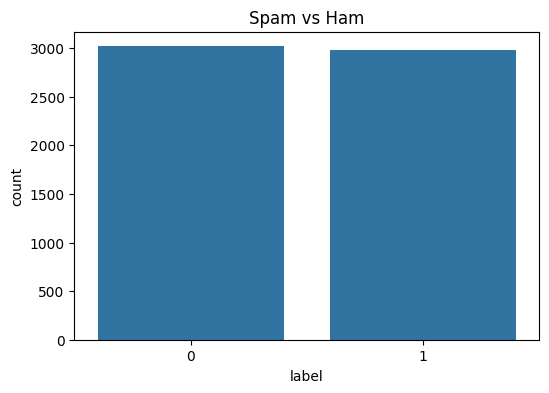

In [42]:
#Plot distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x="label",
    data=email
)

plt.title("Spam vs Ham")

plt.show()

In [43]:
# ==========================================
# Remove Missing Values
# ==========================================

email.dropna(inplace=True)

email.reset_index(drop=True, inplace=True)

In [44]:
# ==========================================
# Message Length
# ==========================================

email["message_length"] = email["text"].apply(len)

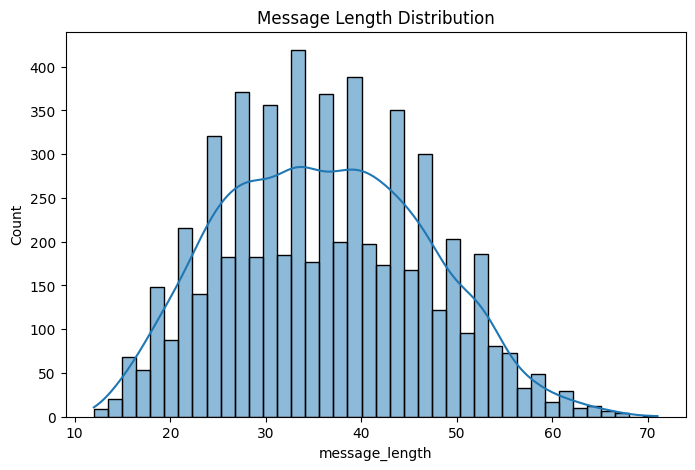

In [45]:
#Message Length Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    email["message_length"],
    bins=40,
    kde=True
)

plt.title("Message Length Distribution")

plt.show()

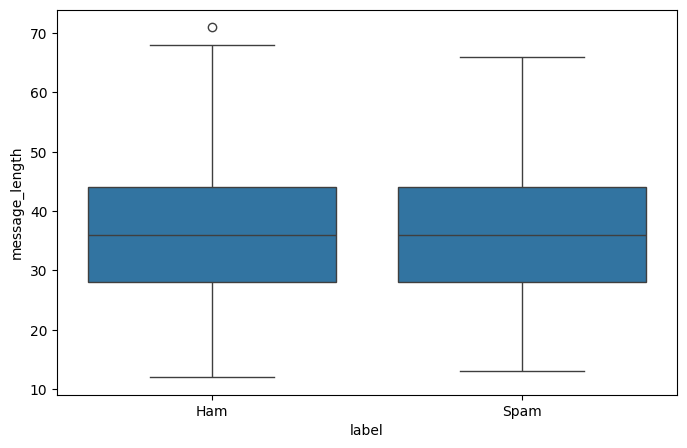

In [46]:
#Box Plot
plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="message_length",
    data=email
)

plt.xticks(
    [0,1],
    ["Ham","Spam"]
)

plt.show()

In [47]:
# ==========================================
# Features and Target
# ==========================================

X2 = email["text"]

y2 = email["label"]

In [48]:
# ==========================================
# Train Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

In [49]:
# ==========================================
# TF-IDF Feature Extraction
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf2 = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X2_train_tfidf = tfidf2.fit_transform(X2_train)

X2_test_tfidf = tfidf2.transform(X2_test)

In [50]:
#MODEL 1 : NAIVE BAYES
from sklearn.naive_bayes import MultinomialNB

nb_model2 = MultinomialNB()

nb_model2.fit(
    X2_train_tfidf,
    y2_train
)

MultinomialNB()

In [51]:
nb_pred2 = nb_model2.predict(
    X2_test_tfidf
)

In [52]:
from sklearn.metrics import accuracy_score

nb_accuracy2 = accuracy_score(
    y2_test,
    nb_pred2
)

print("Naive Bayes Accuracy :", round(nb_accuracy2*100,2),"%")

Naive Bayes Accuracy : 51.25 %


In [53]:
from sklearn.metrics import classification_report

print(classification_report(
    y2_test,
    nb_pred2
))

              precision    recall  f1-score   support

           0       0.52      0.54      0.53       604
           1       0.51      0.49      0.50       596

    accuracy                           0.51      1200
   macro avg       0.51      0.51      0.51      1200
weighted avg       0.51      0.51      0.51      1200



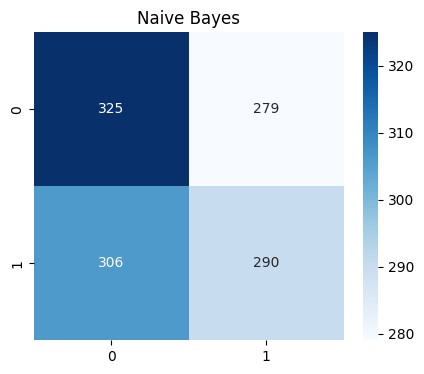

In [54]:
#Confusion Matrix Bayes
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y2_test,
    nb_pred2
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Naive Bayes")

plt.show()

In [55]:
# ==========================================
# MODEL 2 : KNN Model
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

knn_model2 = KNeighborsClassifier(n_neighbors=5)

knn_model2.fit(
    X2_train_tfidf,
    y2_train
)

KNeighborsClassifier()

In [56]:
knn_pred2 = knn_model2.predict(
    X2_test_tfidf
)

In [57]:
# ==========================================
# KNN Accuracy
# ==========================================

knn_accuracy2 = accuracy_score(
    y2_test,
    knn_pred2
)

print("KNN Accuracy :", round(knn_accuracy2*100,2),"%")

KNN Accuracy : 50.0 %


In [58]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(
    y2_test,
    knn_pred2
))

              precision    recall  f1-score   support

           0       0.55      0.04      0.07       604
           1       0.50      0.97      0.66       596

    accuracy                           0.50      1200
   macro avg       0.52      0.50      0.36      1200
weighted avg       0.52      0.50      0.36      1200



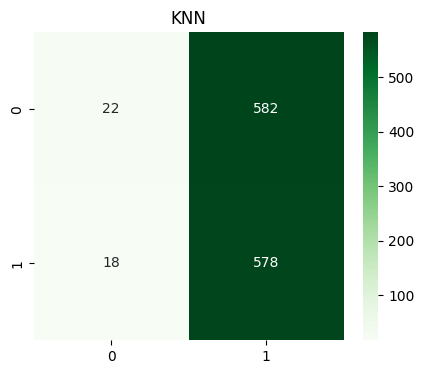

In [59]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y2_test,
    knn_pred2
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("KNN")

plt.show()

In [62]:
# ==========================================
# Model 3 BiLSTM -- Tokenization
# ==========================================
# ==========================================
# Import Deep Learning Libraries
# ==========================================

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout


In [63]:
# ==========================================
# Tokenize Text
# ==========================================

max_words = 5000

max_length = 100

tokenizer2 = Tokenizer(num_words=max_words)

tokenizer2.fit_on_texts(X2_train)

In [64]:
# ==========================================
# Convert Text into Sequence
# ==========================================

X2_train_seq = tokenizer2.texts_to_sequences(X2_train)

X2_test_seq = tokenizer2.texts_to_sequences(X2_test)

In [65]:
# ==========================================
# Padding
# ==========================================

X2_train_pad = pad_sequences(
    X2_train_seq,
    maxlen=max_length,
    padding="post"
)

X2_test_pad = pad_sequences(
    X2_test_seq,
    maxlen=max_length,
    padding="post"
)

print(X2_train_pad.shape)
print(X2_test_pad.shape)

(4800, 100)
(1200, 100)


In [66]:
# ==========================================
# Build BiLSTM Model
# ==========================================

model2 = Sequential()

model2.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_length
    )
)

model2.add(
    Bidirectional(
        LSTM(64)
    )
)

model2.add(
    Dropout(0.5)
)

model2.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [67]:
# ==========================================
# Compile Model
# ==========================================

model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [68]:
# ==========================================
# Train BiLSTM
# ==========================================

history2 = model2.fit(
    X2_train_pad,
    y2_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.5091 - loss: 0.6936 - val_accuracy: 0.5104 - val_loss: 0.6926
Epoch 2/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.5810 - loss: 0.6765 - val_accuracy: 0.5177 - val_loss: 0.7051
Epoch 3/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.6391 - loss: 0.6388 - val_accuracy: 0.5219 - val_loss: 0.7231
Epoch 4/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - accuracy: 0.6721 - loss: 0.5975 - val_accuracy: 0.5063 - val_loss: 0.7937
Epoch 5/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.7174 - loss: 0.5517 - val_accuracy: 0.5052 - val_loss: 0.8311


In [69]:
# ==========================================
# Evaluate Model
# ==========================================

loss2, lstm_accuracy2 = model2.evaluate(
    X2_test_pad,
    y2_test
)

print("BiLSTM Accuracy :", round(lstm_accuracy2*100,2),"%")

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4850 - loss: 0.8323
BiLSTM Accuracy : 48.5 %


In [70]:
# ==========================================
# Prediction
# ==========================================

prediction2 = model2.predict(X2_test_pad)

prediction2 = (prediction2 > 0.5).astype(int)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step


In [71]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(
    y2_test,
    prediction2
))

              precision    recall  f1-score   support

           0       0.49      0.40      0.44       604
           1       0.48      0.57      0.52       596

    accuracy                           0.48      1200
   macro avg       0.49      0.49      0.48      1200
weighted avg       0.49      0.48      0.48      1200



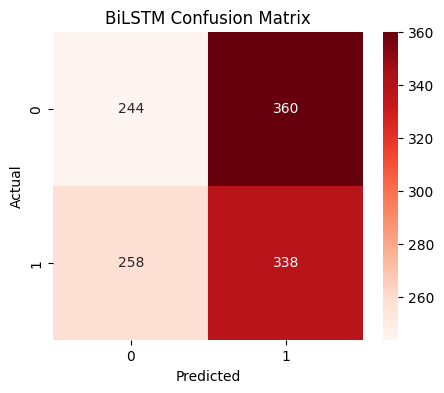

In [72]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y2_test,
    prediction2
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("BiLSTM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [73]:
# ==========================================
# Compare All Models
# ==========================================

comparison2 = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "KNN",
        "BiLSTM"
    ],

    "Accuracy":[
        nb_accuracy2,
        knn_accuracy2,
        lstm_accuracy2
    ]

})

comparison2

,Model,Accuracy
0,Naive Bayes,0.5125
1,KNN,0.5000
2,BiLSTM,0.4850


In [78]:
# ==========================================
# Predict New Email
# ==========================================

sample_email = [
    "Congratulations! You have won a free iPhone. Click the link to claim your prize."
]

sample_tfidf = tfidf2.transform(sample_email)

prediction = nb_model2.predict(sample_tfidf)

if prediction[0] == 1:
    print("Prediction : Spam")
else:
    print("Prediction : Ham")

Prediction : Ham


In [75]:
# ==========================================
# Save BiLSTM Model
# ==========================================

model2.save("dataset2_bilstm_model.keras")

print("BiLSTM Model Saved Successfully")

BiLSTM Model Saved Successfully


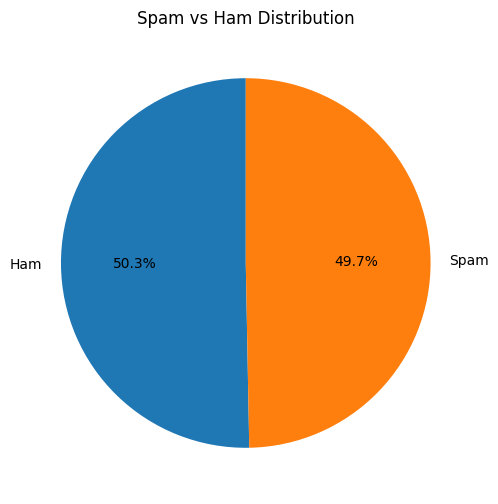

In [79]:
# ==========================================
# Spam vs Ham Pie Chart
# ==========================================

counts = email["label"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=["Ham","Spam"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Spam vs Ham Distribution")

plt.show()

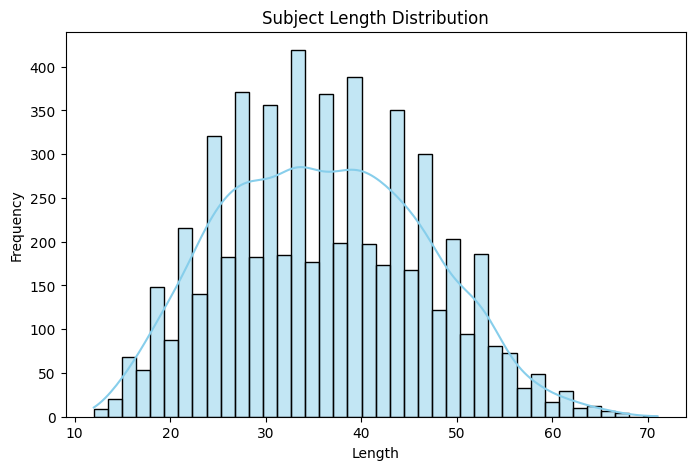

In [80]:
# ==========================================
# Subject Length Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    email["message_length"],
    bins=40,
    kde=True,
    color="skyblue"
)

plt.title("Subject Length Distribution")

plt.xlabel("Length")

plt.ylabel("Frequency")

plt.show()

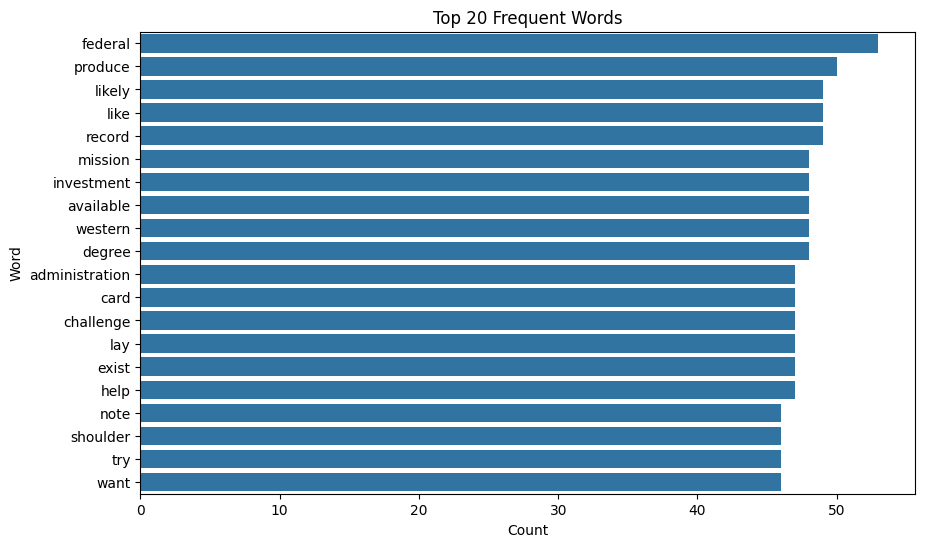

In [82]:
#Top 20 Frequent Words
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    stop_words="english",
    max_features=20
)

X_words = cv.fit_transform(email["text"])

word_counts = X_words.sum(axis=0).A1

words = cv.get_feature_names_out()

word_df = pd.DataFrame({
    "Word": words,
    "Count": word_counts
})

word_df = word_df.sort_values(
    by="Count",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=word_df,
    x="Count",
    y="Word"
)

plt.title("Top 20 Frequent Words")

plt.show()

In [83]:
!pip install wordcloud

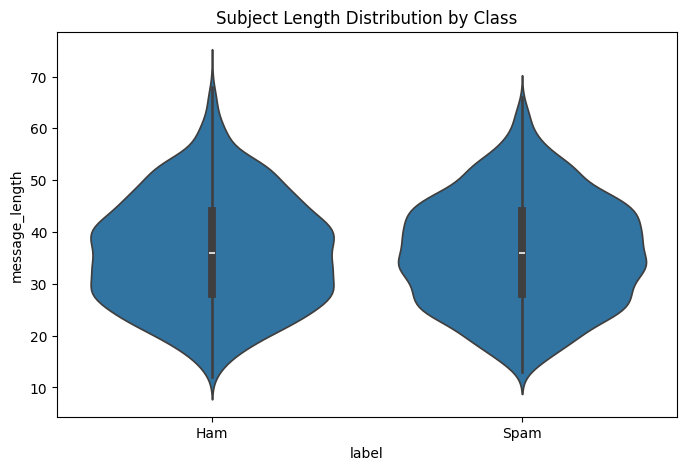

In [86]:
#Subject Length by Class
plt.figure(figsize=(8,5))

sns.violinplot(
    data=email,
    x="label",
    y="message_length"
)

plt.xticks(
    [0,1],
    ["Ham","Spam"]
)

plt.title("Subject Length Distribution by Class")

plt.show()

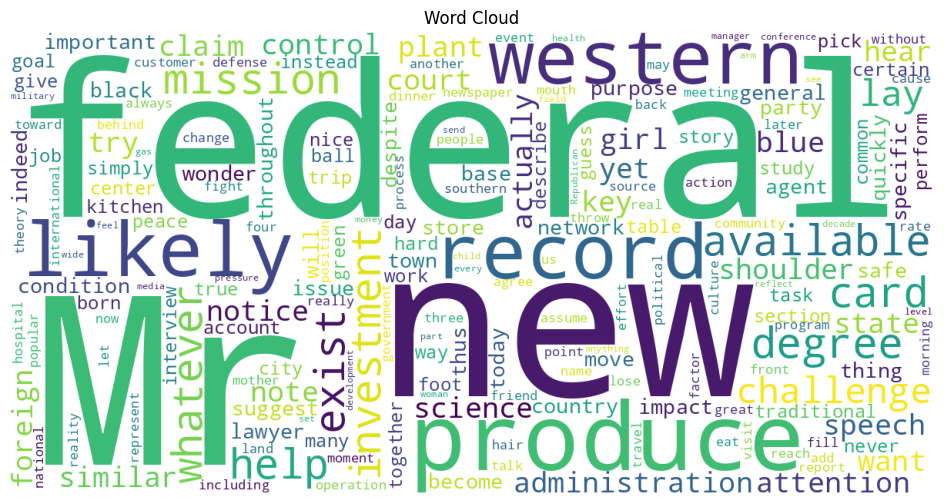

In [87]:
#Wordcloud
from wordcloud import WordCloud

text = " ".join(email["text"])

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.title("Word Cloud")

plt.show()